In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Libraries

In [3]:
from google.colab import files

uploaded = files.upload()

Saving orders.csv to orders.csv


Load Dataset

In [4]:
orders = pd.read_csv('orders.csv')

In [6]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount_Pct,Payment_Method,Order_Status,Campaign_ID,Unit_Price,Unit_Cost,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit,Profit_Margin_Pct
0,ORD00001,2025-01-04,CUST0961,P022,2,0.0,Net Banking,Delivered,CMP005,5915,3970.45,11830,0.0,11830.0,7940.90,3889.10,32.874894
1,ORD00002,2025-05-12,CUST0420,P006,4,0.0,UPI,Delivered,CMP003,4933,3611.45,19732,0.0,19732.0,14445.80,5286.20,26.789986
2,ORD00003,2025-08-06,CUST0249,P007,1,10.0,UPI,Delivered,CMP002,5886,3178.13,5886,588.6,5297.4,3178.13,2119.27,40.005852
3,ORD00004,2025-09-17,CUST0588,P015,1,10.0,COD,Delivered,CMP001,5978,4066.66,5978,597.8,5380.2,4066.66,1313.54,24.414334
4,ORD00005,2025-01-01,CUST0649,P011,4,20.0,Credit Card,Delivered,CMP005,7881,6026.38,31524,6304.8,25219.2,24105.52,1113.68,4.416001


In [7]:
orders.shape

(5012, 17)

Dataset Shape

In [8]:
orders.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Quantity',
       'Discount_Pct', 'Payment_Method', 'Order_Status', 'Campaign_ID',
       'Unit_Price', 'Unit_Cost', 'Gross_Sales', 'Discount_Amount',
       'Net_Sales', 'Cost', 'Profit', 'Profit_Margin_Pct'],
      dtype='object')

Data Types and Information

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           5012 non-null   object 
 1   Order_Date         5012 non-null   object 
 2   Customer_ID        5012 non-null   object 
 3   Product_ID         5012 non-null   object 
 4   Quantity           5012 non-null   int64  
 5   Discount_Pct       4992 non-null   float64
 6   Payment_Method     4987 non-null   object 
 7   Order_Status       5012 non-null   object 
 8   Campaign_ID        4997 non-null   object 
 9   Unit_Price         5012 non-null   int64  
 10  Unit_Cost          5012 non-null   float64
 11  Gross_Sales        5012 non-null   int64  
 12  Discount_Amount    5012 non-null   float64
 13  Net_Sales          5012 non-null   float64
 14  Cost               5012 non-null   float64
 15  Profit             5012 non-null   float64
 16  Profit_Margin_Pct  5012 

Missing Value Analysis

In [10]:
orders.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Product_ID,0
Quantity,0
Discount_Pct,20
Payment_Method,25
Order_Status,0
Campaign_ID,15
Unit_Price,0


In [11]:
orders.duplicated().sum()

np.int64(12)

Duplicate Analysis

In [12]:
orders.describe()

,Quantity,Discount_Pct,Unit_Price,Unit_Cost,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit,Profit_Margin_Pct
count,5012.000000,4992.000000,5012.000000,5012.000000,5012.000000,5012.000000,5012.000000,5012.000000,5012.000000,5012.000000
mean,1.998404,9.576322,5256.491820,3439.478524,10528.223264,1017.870102,9510.353162,6890.961363,2619.391800,27.684036
std,1.078073,7.493120,2037.056973,1447.591746,7323.141090,1206.752608,6657.861616,4957.263142,2191.867782,10.702151
min,1.000000,0.000000,972.000000,537.490000,972.000000,0.000000,729.000000,537.490000,-677.200000,-3.507900
25%,1.000000,5.000000,4817.000000,2793.690000,5137.000000,97.200000,4782.400000,3178.130000,1066.520000,20.318353
50%,2.000000,10.000000,5886.000000,3830.780000,7713.000000,627.600000,7022.400000,5142.330000,1973.090000,29.066731
75%,3.000000,15.000000,6748.000000,4299.970000,14904.000000,1445.100000,13401.675000,9991.100000,3649.940000,36.160058
max,4.000000,25.000000,7881.000000,6026.380000,31524.000000,7745.000000,31524.000000,24105.520000,13780.120000,46.005267


Descriptive Statistics

In [14]:
orders['Order_Status'].value_counts()

,count
Order_Status,
Delivered,3849
Cancelled,510
Returned,355
Shipped,298


In [15]:
orders['Order_Status'].value_counts(normalize=True) * 100

,proportion
Order_Status,
Delivered,76.795690
Cancelled,10.175579
Returned,7.083001
Shipped,5.945730


Order Status Analysis

In [16]:
orders['Payment_Method'].value_counts()

,count
Payment_Method,
Net Banking,1090
UPI,996
Debit Card,991
COD,964
Credit Card,946


Payment Method Analysis

In [18]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

In [19]:
orders['Order_Date'].dtype

dtype('<M8[ns]')

Convert Order Date

In [20]:
orders.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Product_ID,0
Quantity,0
Discount_Pct,20
Payment_Method,25
Order_Status,0
Campaign_ID,15
Unit_Price,0


Check missing values again

In [21]:
orders.duplicated().sum()

np.int64(12)

In [22]:
orders = orders.drop_duplicates()

Remove exact duplicate rows

In [23]:
orders.shape

(5000, 17)

Check the cleaned dataset

In [24]:
orders['Year'] = orders['Order_Date'].dt.year
orders['Month'] = orders['Order_Date'].dt.month
orders['Month_Name'] = orders['Order_Date'].dt.month_name()

In [25]:
orders[['Order_Date', 'Year', 'Month', 'Month_Name']].head()

,Order_Date,Year,Month,Month_Name
0,2025-01-04,2025,1,January
1,2025-05-12,2025,5,May
2,2025-08-06,2025,8,August
3,2025-09-17,2025,9,September
4,2025-01-01,2025,1,January


Create useful date columns

In [28]:
monthly_revenue = (
    orders.groupby(['Year', 'Month'])['Net_Sales']
    .sum()
    .reset_index()
)

monthly_revenue

,Year,Month,Net_Sales
0,2025,1,4383826.40
1,2025,2,3748688.05
2,2025,3,4102523.80
3,2025,4,4267224.25
4,2025,5,3878080.70
5,2025,6,3805577.90
6,2025,7,4353289.55
7,2025,8,3720345.05
8,2025,9,3596734.40
9,2025,10,3687487.75


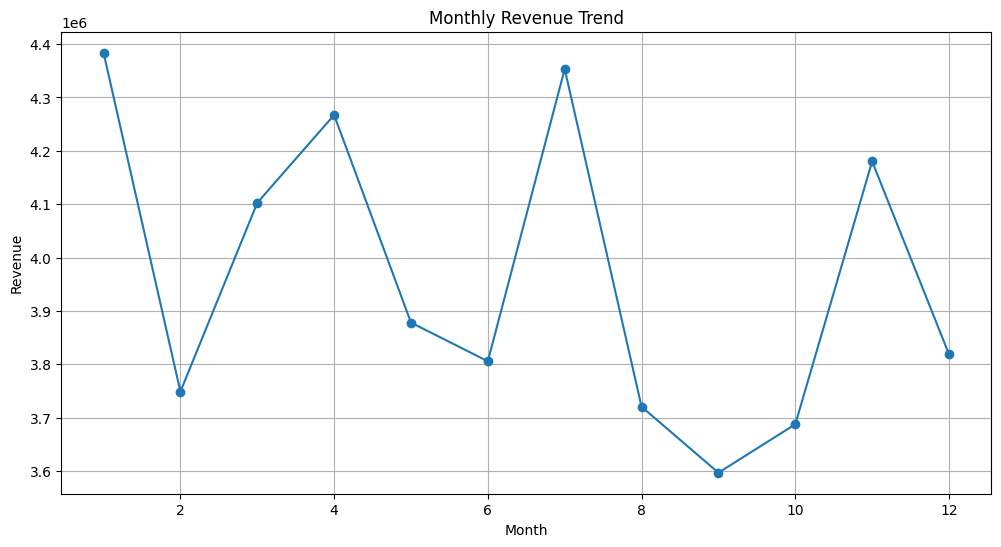

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['Month'],
    monthly_revenue['Net_Sales'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

Monthly Revenue Trend


In [32]:
payment_counts = orders['Payment_Method'].value_counts()

payment_counts

,count
Payment_Method,
Net Banking,1089
UPI,994
Debit Card,988
COD,961
Credit Card,943


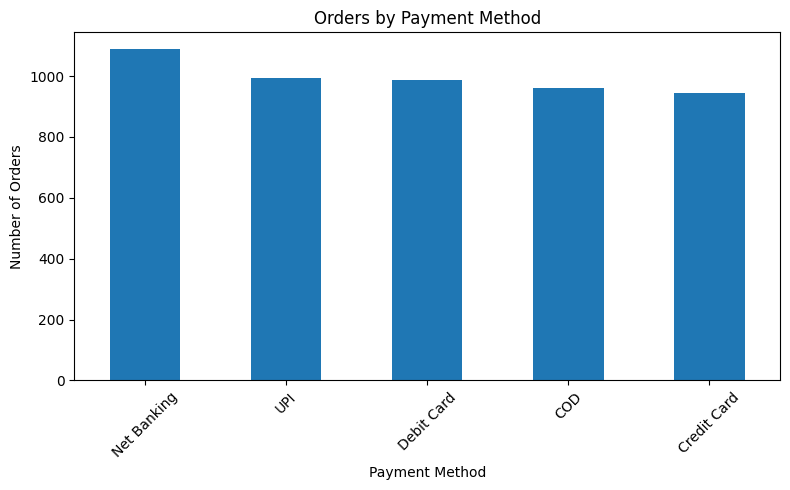

In [33]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind='bar')

plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Payment Method Analysis

In [34]:
status_counts = orders['Order_Status'].value_counts()

status_counts

,count
Order_Status,
Delivered,3839
Cancelled,509
Returned,354
Shipped,298


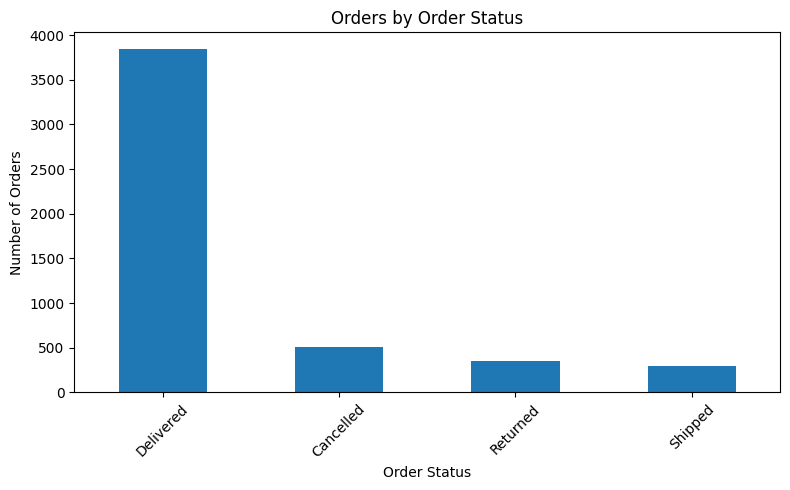

In [35]:
plt.figure(figsize=(8, 5))

status_counts.plot(kind='bar')

plt.title('Orders by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Order Status Analysis

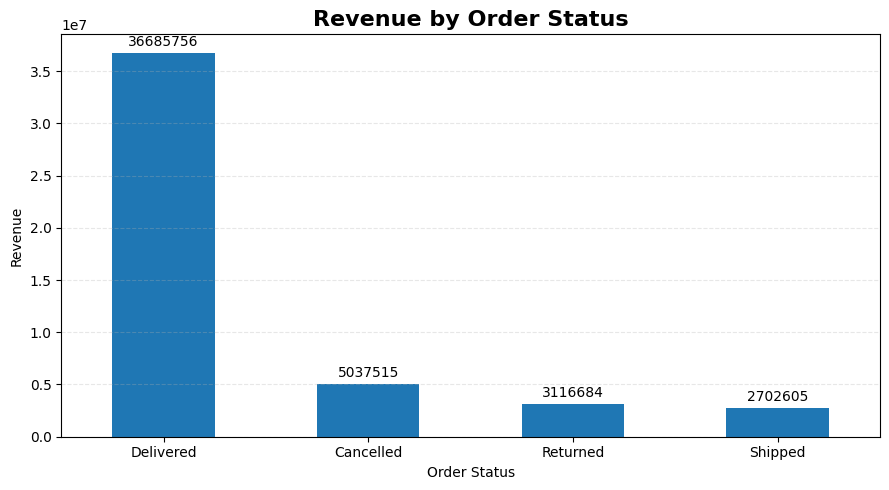

In [37]:
revenue_status = (
    orders.groupby('Order_Status')['Net_Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = revenue_status.plot(kind='bar')

plt.title('Revenue by Order Status', fontsize=16, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Revenue Distribution

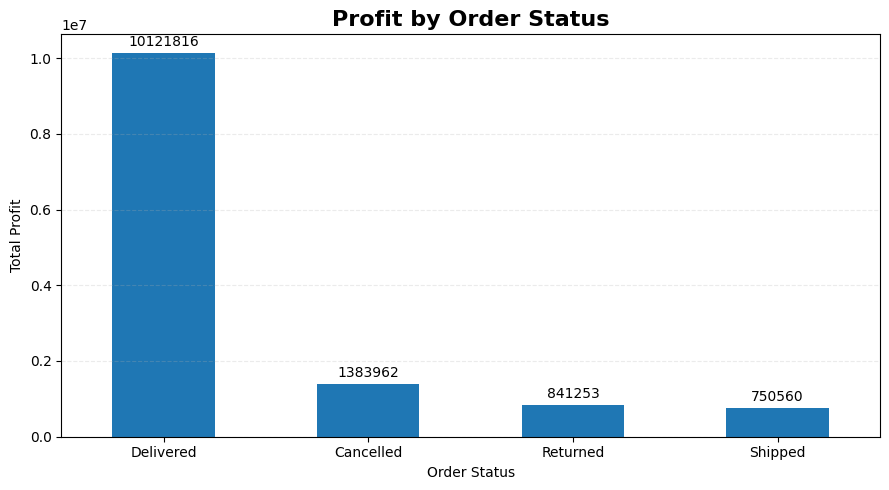

In [39]:
profit_status = (
    orders.groupby('Order_Status')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = profit_status.plot(kind='bar', figsize=(9, 5))

plt.title('Profit by Order Status', fontsize=16, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.25)

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Profit Distribution

In [40]:
monthly_profit = (
    orders.groupby(['Year', 'Month'])['Profit']
    .sum()
    .reset_index()
)

monthly_profit

,Year,Month,Profit
0,2025,1,1176429.86
1,2025,2,1014534.31
2,2025,3,1164433.15
3,2025,4,1212897.02
4,2025,5,1086086.16
5,2025,6,1047180.56
6,2025,7,1220287.50
7,2025,8,1023813.42
8,2025,9,1002742.53
9,2025,10,1015796.93


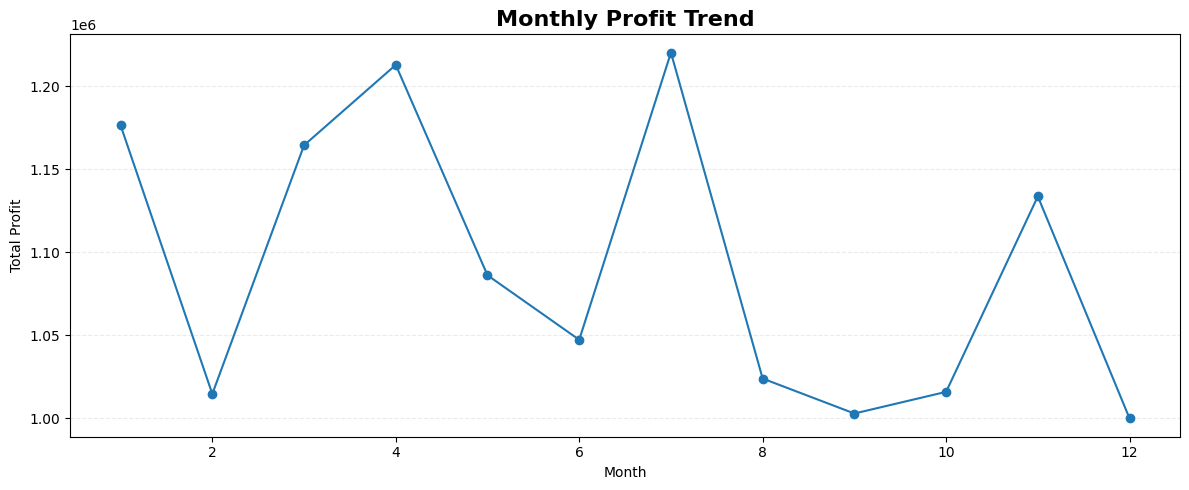

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_profit['Month'],
    monthly_profit['Profit'],
    marker='o'
)

plt.title('Monthly Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

Monthly Profit Trend

In [42]:
aov_status = (
    orders.groupby('Order_Status')['Net_Sales']
    .mean()
    .sort_values(ascending=False)
)

aov_status

,Net_Sales
Order_Status,
Cancelled,9896.886248
Delivered,9556.070800
Shipped,9069.144799
Returned,8804.191949


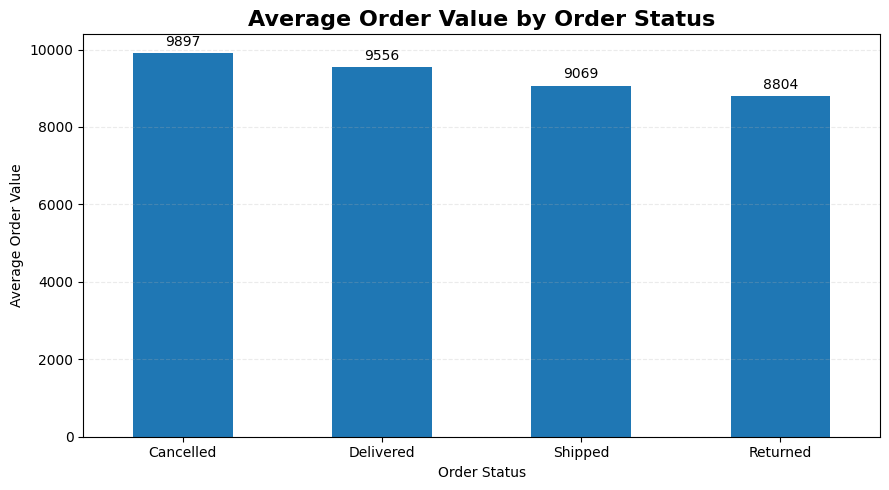

In [43]:
plt.figure(figsize=(9, 5))

ax = aov_status.plot(kind='bar')

plt.title('Average Order Value by Order Status',
          fontsize=16, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('Average Order Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Average Order Value


In [44]:
numeric_data = orders.select_dtypes(include=np.number)

correlation = numeric_data.corr()

correlation

,Quantity,Discount_Pct,Unit_Price,Unit_Cost,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit,Profit_Margin_Pct,Year,Month
Quantity,1.000000,0.012807,0.009093,0.009888,0.778711,0.469832,0.771108,0.753246,0.638327,-0.010885,NaN,-0.027988
Discount_Pct,0.012807,1.000000,-0.000849,-0.001204,0.015135,0.661670,-0.103107,0.013464,-0.343339,-0.588146,NaN,0.015620
Unit_Price,0.009093,-0.000849,1.000000,0.955007,0.559958,0.334941,0.555016,0.560572,0.417843,-0.134329,NaN,0.007630
Unit_Cost,0.009888,-0.001204,0.955007,1.000000,0.535318,0.317681,0.531050,0.586849,0.285734,-0.343617,NaN,0.005472
Gross_Sales,0.778711,0.015135,0.559958,0.535318,1.000000,0.606844,0.989603,0.980567,0.787819,-0.086816,NaN,-0.018118
Discount_Amount,0.469832,0.661670,0.334941,0.317681,0.606844,1.000000,0.486219,0.591950,0.138143,-0.428512,NaN,0.012069
Net_Sales,0.771108,-0.103107,0.555016,0.531050,0.989603,0.486219,1.000000,0.970934,0.841142,-0.017906,NaN,-0.022103
Cost,0.753246,0.013464,0.560572,0.586849,0.980567,0.591950,0.970934,1.000000,0.687249,-0.210787,NaN,-0.017824
Profit,0.638327,-0.343339,0.417843,0.285734,0.787819,0.138143,0.841142,0.687249,1.000000,0.421933,NaN,-0.026808
Profit_Margin_Pct,-0.010885,-0.588146,-0.134329,-0.343617,-0.086816,-0.428512,-0.017906,-0.210787,0.421933,1.000000,NaN,-0.007519


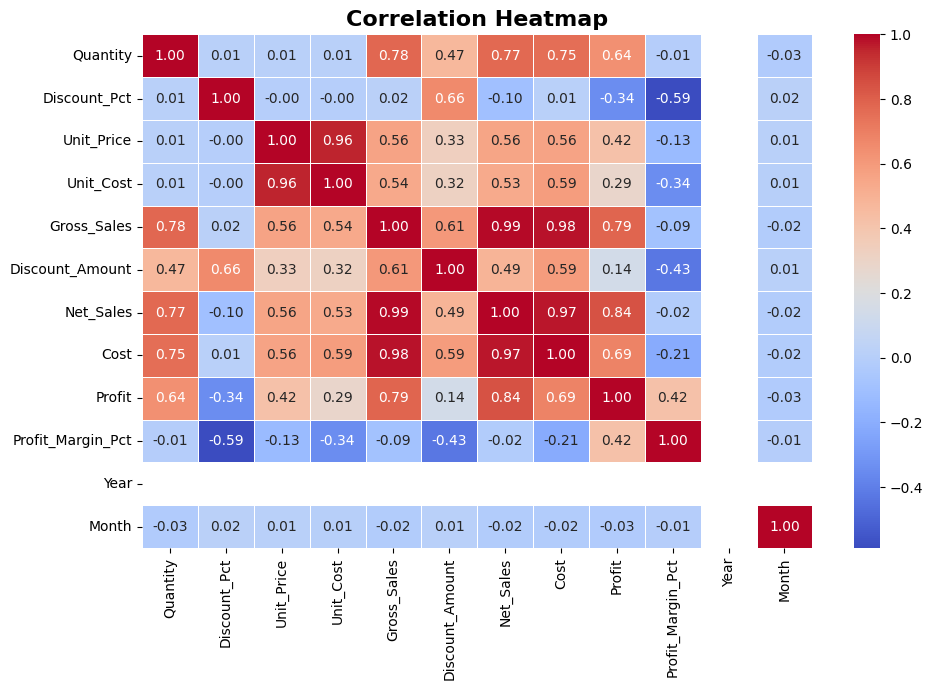

In [45]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap',
          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

Correlation Analysis

## 20. Key Business Insights

###  Revenue & Profit
- The analysis shows the overall revenue and profit performance of the e-commerce business.
- Net Sales and Profit have a strong positive relationship, indicating that higher sales are generally associated with higher profit.

###  Order Performance
- The average order value helps measure the typical revenue generated per order.
- Order status analysis shows the distribution of delivered, cancelled, and other orders.

###  Payment Behavior
- Payment method analysis identifies the most frequently used payment method among customers.

###  Sales Trend
- Monthly revenue analysis helps identify periods of higher and lower sales performance.
- Monthly profit analysis highlights the periods with the strongest profitability.

###  Correlation Findings
- Gross Sales and Net Sales show a very strong positive relationship.
- Unit Price and Unit Cost also show a strong positive relationship.
- Discount percentage has a negative relationship with Profit Margin, suggesting that higher discounts are associated with lower margins.

###  Business Recommendation
- Monitor discount levels carefully to protect profit margins.
- Focus on improving sales during weaker-performing periods.
- Track high-value orders and customer purchasing behavior to improve revenue and profitability.

##  Conclusion

The exploratory data analysis provided insights into the e-commerce business's
sales, profit, order behavior, payment methods, and key business metrics.

The analysis identified important relationships between sales, cost, profit,
and discount levels. These findings can help the business monitor profitability,
optimize discount strategies, and identify opportunities to improve sales
performance.

The insights from Python EDA were further used to support the final Power BI
dashboard and business recommendations.